## Physical Processes in Lake Zug

In [1]:
# imports
import ewgreaders as ewg
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm
import os
from glob import glob

In [4]:
lake = 'Zug'

di_ctd = ewg.get_data_index(lake, 'ctd')
di_m = ewg.get_data_index(lake, 'mooring')

In [5]:
def load_adcp_chain(di, gap):
    # ADCP
    all_adcp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        t_start = deploy + pd.Timedelta(days=1)
        t_end = retrieve - pd.Timedelta(days=1)
        areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
        ds = areader.load().sel(time=slice(t_start, t_end))
        ds['depth'] = ds['depth'].round(0)
        ds = ewg.signal.valid_depths(ds, 0.5)    # keep depth bins with > 50% data
        all_adcp.append(ds)

    # shared time axis as mean of each instruments times
    time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
    all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

    # concatenate datasets and average common range bins
    ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
    ds_adcp = ds_adcp.sortby('depth')
    ds_adcp = ds_adcp.groupby('depth').mean()

    # don't interplate over gap from opposite looking ADCPs in double frame
    full_depth = np.sort(np.concatenate([ds_adcp.depth.values, gap]))
    ds_adcp = ds_adcp.reindex(depth=full_depth)

    return ds_adcp


def load_thermistor_chain(di):
    all_temp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        t_start = deploy + pd.Timedelta(days=1)
        t_end = retrieve - pd.Timedelta(days=1)
        treader = ewg.thermistor_reader.ThermistorReader(row.lake, row.date, row.location, row.serial_id)
        ds = treader.load().sel(time=slice(t_start, t_end))
        all_temp.append(ds)

    ds_temp = mreader.create_instrument_chain(all_temp)

    return ds_temp

def load_oxygen_logger_chain(di):
    all_do = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        t_start = deploy + pd.Timedelta(days=1)
        t_end = retrieve - pd.Timedelta(days=1)
        oreader = ewg.o2_reader.O2Reader(row.lake, row.date, row.location, row.serial_id)
        ds = oreader.load().sel(time=slice(t_start, t_end))
        
        #anoxic region
        if ds['depth'] > 100:
            ds['do2_conc'] = ds['do2_conc'] - ds['do2_conc'].min()

        all_do.append(ds)

    ds_do = mreader.create_instrument_chain(all_do)

    return ds_do

def hz_to_hr(freq):
    return (1/freq) / 3600

def hr_to_hz(period):
    return 1 / (period * 3600)

### Gravity Current

Southward current along bottom (LZN, LZC) or at interface (LZC) following cooling. 

In [3]:
t_start = '2025-10-31'
t_end = '2026-04-10'

In [4]:
all_ds = []
for year in ['2025', '2026']:
    meteo_path = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Meteo/meteo_cham.nc'
    ds = xr.open_dataset(meteo_path)
    all_ds.append(ds)

ds_meteo = xr.concat(all_ds, dim='time')
ds_meteo = ds_meteo.sel(time=slice(t_start, t_end))

# air temperature, 1-day rolling average
air_temp = ds_meteo['air_temp']
air_temp_ra = air_temp.rolling(time=6*24, center=True).mean()

In [5]:
pl_n = ["P1", "P2", "P3", "P4", "VMPN"]
pl_c = ["P6", "VMPC", "PC", "P7"]
pl_s = ["P10", "VMPS", "LZ3", "P11", "P12"]

di_ctd_sel = di_ctd[di_ctd['date'].between(t_start, t_end)]

In [6]:
surf_temp = []
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()
    surf_temp.append({
        'date': p.date,
        'temp': ds['temp'].isel(depth=0).item()
    })

surf_temp = pd.DataFrame(surf_temp)
#surf_temp = surf_temp.groupby('date').mean().reset_index()

  0%|          | 0/187 [00:00<?, ?it/s]

In [7]:
t0 = pd.to_datetime('2025-12-16')
tf = pd.to_datetime('2026-01-31')

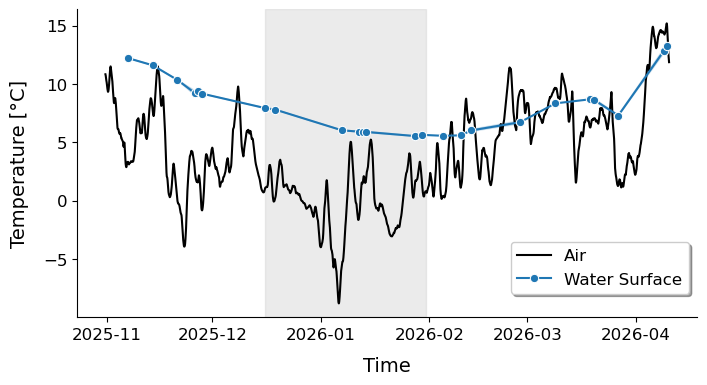

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.axvspan(t0, tf, color='silver', alpha=0.3)
sns.lineplot(x=air_temp_ra.time, y=air_temp_ra, color='black', ax=ax, label='Air')
sns.lineplot(surf_temp, x='date', y='temp', color='tab:blue', marker='o', ax=ax, errorbar=('se', 1), err_style='band', label='Water Surface')

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Temperature [°C]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

ax.legend(fontsize=12, ncols=1, shadow=True, loc='lower right', bbox_to_anchor=(1, 0.05))

plt.savefig('../gallery/zug_retreat/air_surfwater_temp.svg', bbox_inches='tight')
plt.show()

In [10]:
di_ctd_sel = di_ctd[(di_ctd['date'].between(t0, tf)) & (di_ctd['profile_loc'].isin(pl_c))]

data = []
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()
    rho = ds['rho']
    rho_ra = ewg.signal.binned_average_z(rho)
    dat = pd.DataFrame({'depth': rho_ra.depth, 'rho': rho_ra})
    dat[['date', 'time']] = ds.attrs['date'], ds.attrs['time']
    data.append(dat)

data = pd.concat(data, ignore_index=True)

# for plotting
data = data[data['depth'] > 5]
data['rho'] = data['rho'] - 1e3

  0%|          | 0/21 [00:00<?, ?it/s]

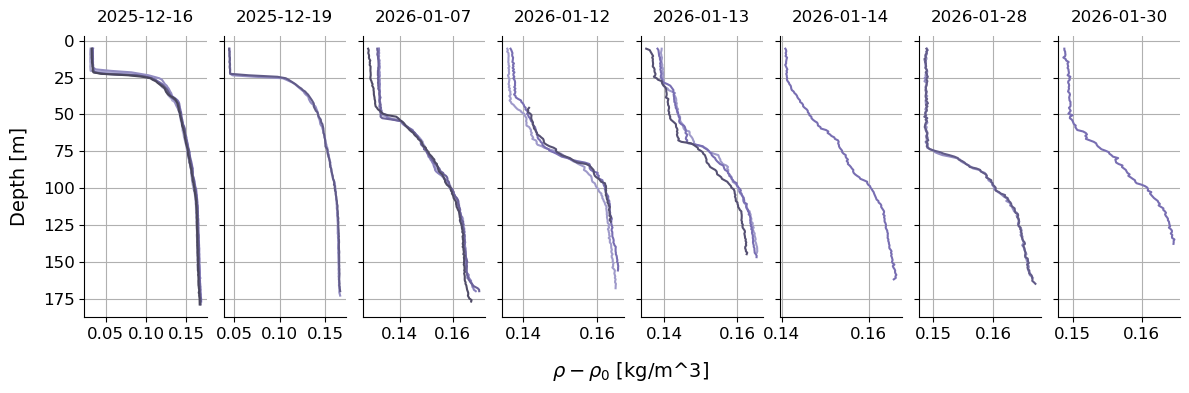

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=data['date'].nunique(), figsize=(12, 4), sharey=True)

for i, (t, dat) in enumerate(data.groupby('date')):
    sns.lineplot(dat, x='rho', y='depth', orient='y', hue='time', palette='Purples_d', ax=ax[i], legend=False)

    ax[i].set_xlabel('')
    ax[i].set_title(t, fontsize=12, pad=10)
    ax[i].tick_params(axis='both', labelsize=12)

    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
fig.supxlabel(r'$\rho - \rho_{0}$ [kg/m^3]', fontsize=14, x=0.53, y=0.03)

ax[0].invert_yaxis()

plt.tight_layout(w_pad=0)
plt.savefig('../gallery/zug_retreat/rho_pycnocline.svg', bbox_inches='tight')
plt.show()

In [13]:
date = '2026-01-14'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(67, 77)

ds_adcp = load_adcp_chain(di_m_sel, gap)
vel1 = ds_adcp.vel.sel(time=slice(t0, tf))

C:\Users\herremha\AppData\Local\Temp\ipykernel_22788\1381314648.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_22788\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [14]:
date = '2026-04-09'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(77, 87)

ds_adcp = load_adcp_chain(di_m_sel, gap)
vel2 = ds_adcp.vel.sel(time=slice(t0, tf))

C:\Users\herremha\AppData\Local\Temp\ipykernel_22788\2926341980.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_22788\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [15]:
# align depths (interpolate over mismatched depth bins)
aligned_depth = np.arange(vel1.depth.min(), vel2.depth.max())
vel1_aligned = vel1.reindex(depth=aligned_depth, method='nearest', tolerance=1)
vel2_aligned = vel2.reindex(depth=aligned_depth, method='nearest', tolerance=1)
vel = xr.concat([vel1_aligned, vel2_aligned], dim="time")

# don't interplate over time gap
gap = pd.date_range(vel1.time.values[-1], vel2.time.values[0], freq='10min')
full_time = np.sort(np.concatenate([vel.time.values, gap]))
vel = vel.reindex(time=full_time)

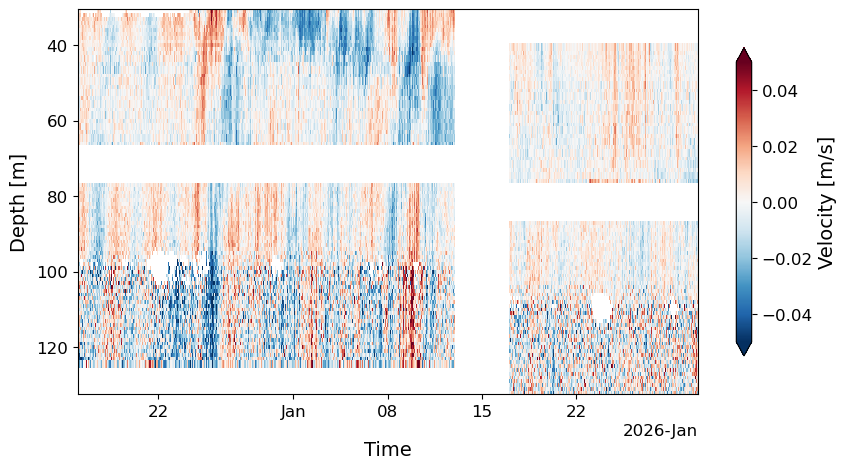

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

pc = vel.sel(dir='N').plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink': 0.8, 'label': 'Velocity [m/s]'}, ax=ax, rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()

plt.savefig('../gallery/zug_retreat/vel_interfacial_current.svg', bbox_inches='tight')
plt.show()

### Internal Seiche

In [3]:
t_start = '2025-10-31'
t_end = '2026-04-10'

all_ds = []
for year in ['2025', '2026']:
    meteo_path = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Meteo/meteo_cham.nc'
    ds = xr.open_dataset(meteo_path)
    all_ds.append(ds)

ds_meteo = xr.concat(all_ds, dim='time')
ds_meteo = ds_meteo.sel(time=slice(t_start, t_end))

# wind speed and direction, 1-day rolling average
wind_speed = ds_meteo['wind_speed']
wind_dir = ds_meteo['wind_direction']
wind_speed_ra = wind_speed.rolling(time=6*24, center=True).mean()

In [6]:
date = '2026-01-14'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(67, 77)

ds_adcp = load_adcp_chain(di_m_sel, gap)
vel1 = ds_adcp.vel.sel(time=slice(t_start, t_end))

C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\3438773690.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [7]:
date = '2026-04-09'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(77, 87)

ds_adcp = load_adcp_chain(di_m_sel, gap)
vel2 = ds_adcp.vel.sel(time=slice(t_start, t_end))

C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\2032037679.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [53]:
sfreq = 1/600    # Hz

data = []
for d in vel2.depth.values:
    v2 = vel2.sel(dir='N', depth=d).dropna(dim='time')

    if len(v2) > 0:
        # detrend
        v2 = scipy.signal.detrend(v2, type='linear')
        
        # spectral decomposition
        freqs, psd = scipy.signal.welch(v2, fs=sfreq, nperseg=2048)    # 1800 points = 300 hours

        dat = pd.DataFrame({
            'freq': freqs[1:],
            'period': (1/freqs[1:]) / 3600,
            'power': psd[1:]
        })
        dat['depth'] = d
        data.append(dat)

psd = pd.concat(data, ignore_index=True)
psd = psd[psd['period'] > 0.5]

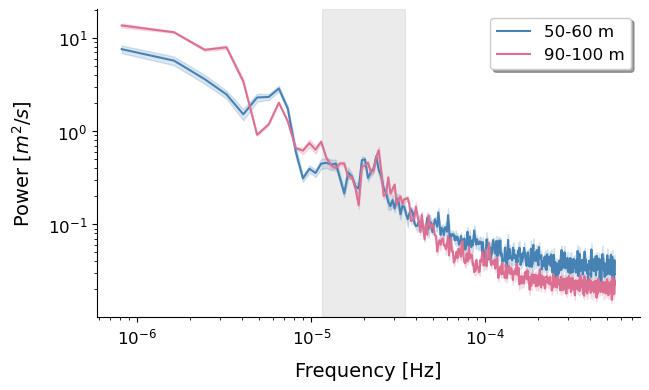

In [57]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(psd[psd['depth'].between(50, 60)], x='freq', y='power', color='steelblue', errorbar=('se', 1), ax=ax, label='50-60 m')
sns.lineplot(psd[psd['depth'].between(90, 100)], x='freq', y='power', color='palevioletred', errorbar=('se', 1), ax=ax, label='90-100 m')

ax.set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
ax.set_ylabel(r'Power [$m^{2}/s$]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper right')

plt.savefig('../gallery/zug_retreat/vel_psd.svg', bbox_inches='tight')
plt.show()

In [58]:
sfreq = 1/600          # Hz
nps = 3*24*6           # 3-day window
nol = int(nps * 0.5)    # 50% overlap

data = []
for d in vel2.depth.values:
    v2 = vel2.sel(dir='N', depth=d)

    if v2.notnull().all():
        # time-frequency
        freqs, t, pows = scipy.signal.spectrogram(v2, fs=sfreq, nperseg=nps, noverlap=nol, detrend='linear', scaling='density')

        freqs = freqs[1:]
        period = (1/freqs) / 3600
        pows = pows[1:]
        t = v2.time.values[0] + pd.to_timedelta(t, unit='s')

        # create xarray DataArray
        da = xr.DataArray(data=pows, dims=['period', 'time'], coords={'period': period, 'time': t, 'freqs': (['period'], freqs)}, name='spectral_power_density')
        da = da.assign_coords(depth=d)
        data.append(da)

pows = xr.concat(data, dim='depth')

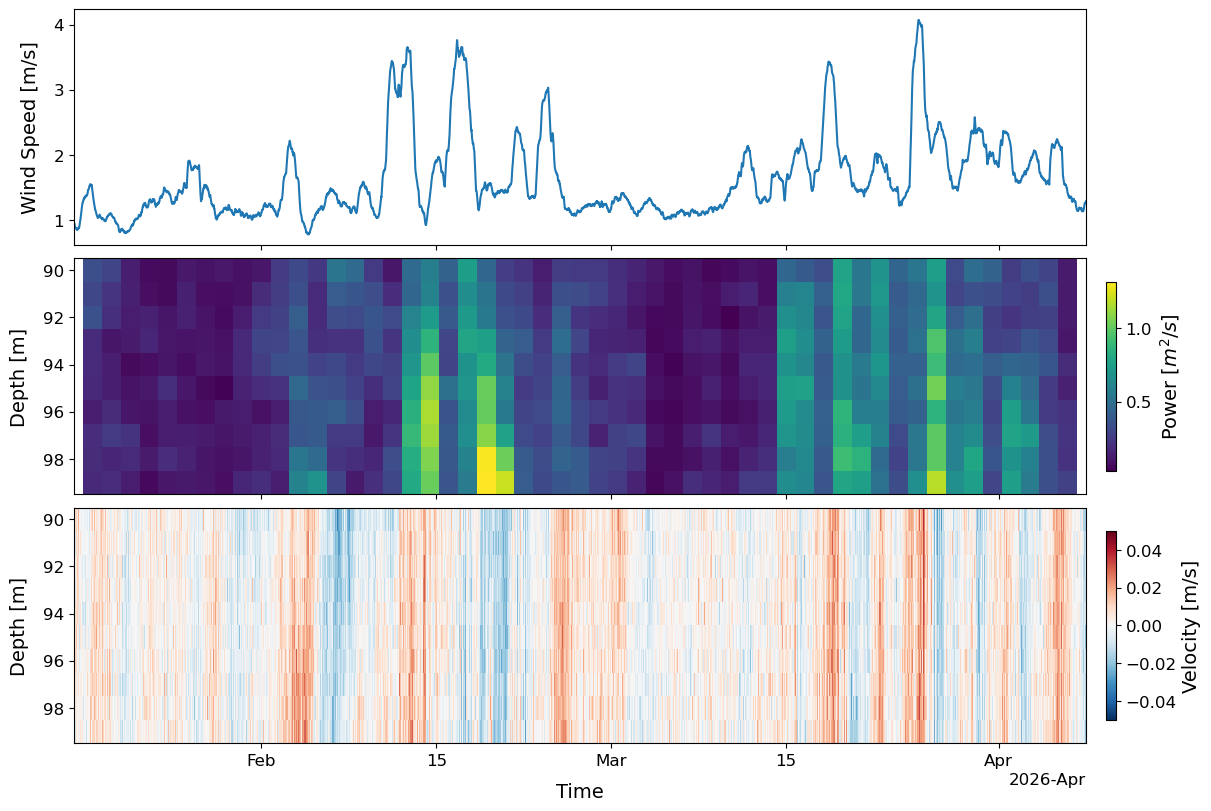

In [59]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True, layout='constrained')

# wind speed
sns.lineplot(x=wind_speed_ra.sel(time=slice(v2.time.values[0], v2.time.values[-1])).time, y=wind_speed_ra.sel(time=slice(v2.time.values[0], v2.time.values[-1])), color='tab:blue',ax=ax[0])

pc = pows.sel(period=slice(24, 8), depth=slice(90, 99)).mean(dim='period').plot(x='time', y='depth', cbar_kwargs={'shrink': 0.8, 'pad': 0.02, 'label': r'Power [$m^{2}/s$]'}, ax=ax[1], rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)

pc = vel2.sel(dir='N', depth=slice(90, 99)).plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink': 0.8, 'pad': 0.02, 'label': 'Velocity [m/s]'}, ax=ax[2], rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)
ax[2].xaxis.get_offset_text().set_fontsize(12)

ax[1].set_xlabel('')
ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Wind Speed [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[2].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[2].set_title('')

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)

ax[1].invert_yaxis()
ax[2].invert_yaxis()

plt.savefig('../gallery/zug_retreat/internal_seiche.svg', bbox_inches='tight')
plt.show()

In [65]:
date = '2026-04-09'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor in ['rbr_temp', 'rbr_duet']")

ds_temp = load_thermistor_chain(di_m_sel)

C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\3811099040.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor in ['rbr_temp', 'rbr_duet']")
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [73]:
sfreq = 1/600    # Hz

data = []
for d in ds_temp.depth.values:
    temp = ds_temp.temp.sel(depth=d).dropna(dim='time')

    # detrend
    temp = scipy.signal.detrend(temp, type='linear')
    
    # spectral decomposition
    freqs, psd = scipy.signal.welch(temp, fs=sfreq, nperseg=2048)    # 1800 points = 300 hours

    dat = pd.DataFrame({
        'freq': freqs[1:],
        'period': (1/freqs[1:]) / 3600,
        'power': psd[1:]
    })
    dat['depth'] = d
    data.append(dat)

psd_temp = pd.concat(data, ignore_index=True)
psd_temp = psd_temp[psd_temp['period'] > 0.5]

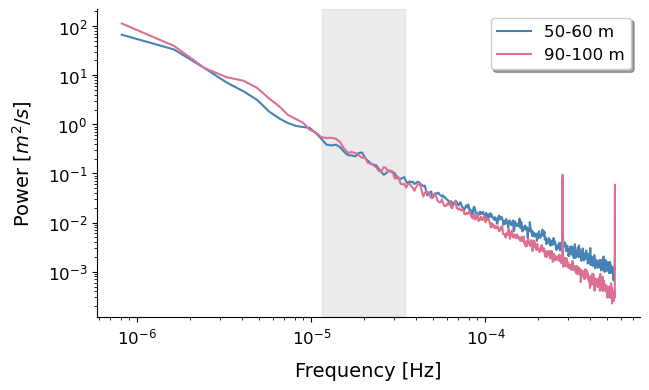

In [75]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(psd_temp[psd_temp['depth'].between(50, 60)], x='freq', y='power', color='steelblue', errorbar=('se', 1), ax=ax, label='50-60 m')
sns.lineplot(psd_temp[psd_temp['depth'].between(90, 100)], x='freq', y='power', color='palevioletred', errorbar=('se', 1), ax=ax, label='90-100 m')

ax.set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
ax.set_ylabel(r'Power [$m^{2}/s$]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper right')

plt.savefig('../gallery/zug_retreat/temp_psd.svg', bbox_inches='tight')
plt.show()

In [80]:
date = '2026-04-09'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'minidot'")

ds_do = load_oxygen_logger_chain(di_m_sel)

C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\266964024.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'minidot'")
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [81]:
sfreq = 1/600    # Hz

data = []
for d in ds_do.depth.values:
    do = ds_do.do2_conc.sel(depth=d).dropna(dim='time')

    # detrend
    do = scipy.signal.detrend(do, type='linear')
    
    # spectral decomposition
    freqs, psd = scipy.signal.welch(do, fs=sfreq, nperseg=2048)    # 1800 points = 300 hours

    dat = pd.DataFrame({
        'freq': freqs[1:],
        'period': (1/freqs[1:]) / 3600,
        'power': psd[1:]
    })
    dat['depth'] = d
    data.append(dat)

psd_do = pd.concat(data, ignore_index=True)
psd_do = psd_do[psd_do['period'] > 0.5]

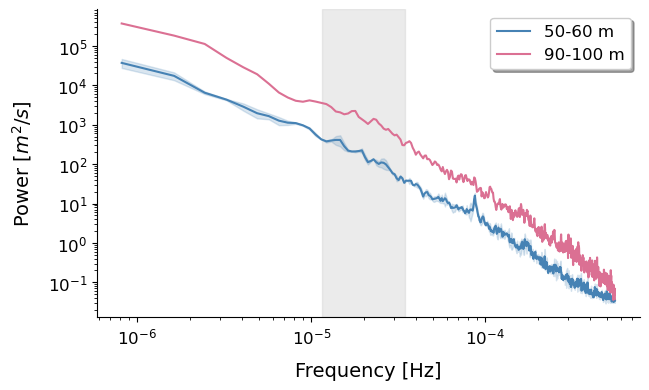

In [82]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.axvspan(hr_to_hz(24), hr_to_hz(8), color='silver', alpha=0.3)
sns.lineplot(psd_do[psd_do['depth'].between(50, 60)], x='freq', y='power', color='steelblue', errorbar=('se', 1), ax=ax, label='50-60 m')
sns.lineplot(psd_do[psd_do['depth'].between(90, 100)], x='freq', y='power', color='palevioletred', errorbar=('se', 1), ax=ax, label='90-100 m')

ax.set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
ax.set_ylabel(r'Power [$m^{2}/s$]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper right')

plt.savefig('../gallery/zug_retreat/do_psd.svg', bbox_inches='tight')
plt.show()

#### Seiche + deep mixing

Oxyen at 125 m, N-S velocity averaged over 120-130 m at constriction center.

In [263]:
do = ds_do.do2_conc.sel(depth=125, method='nearest')
v = vel2.sel(dir='N', depth=slice(120, 130)).mean(dim='depth')

# re-sample O2 to 10-min intervals
do_rs = do.resample(time='10min').mean()

# dO2/dt
dodt = do_rs.differentiate('time')

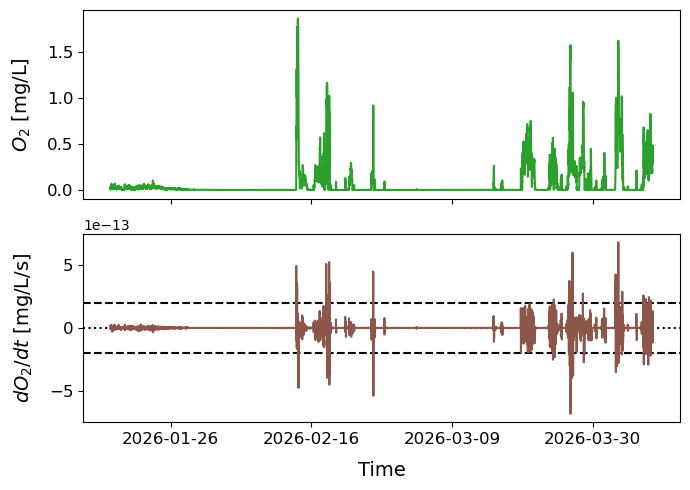

In [296]:
thresh = 2e-13

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(7, 5), sharex=True)

sns.lineplot(x=do_rs.time, y=do_rs, color='tab:green', ax=ax[0])

ax[1].axhline(0, color='black', linestyle=':')
ax[1].axhline(thresh, color='black', linestyle='--')
ax[1].axhline(-thresh, color='black', linestyle='--')
sns.lineplot(x=dodt.time, y=dodt, color='tab:brown', ax=ax[1])

ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel(r'$O_2$ [mg/L]', fontsize=14, labelpad=10)
ax[1].set_ylabel(r'$dO_2/dt$ [mg/L/s]', fontsize=14, labelpad=10)
ax[0].tick_params(axis='both', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)
ax[1].xaxis.set_major_locator(mdates.DayLocator(interval=21))

plt.tight_layout()
plt.savefig('../gallery/zug_retreat/do_dodt.svg', bbox_inches='tight')
plt.show()

In [270]:
mask_pos = dodt > thresh
t_pos = dodt.time.where(mask_pos, drop=True)

mask_neg = dodt < -thresh
t_neg = dodt.time.where(mask_neg, drop=True)

v_pos = v.reindex(time=t_pos, method='nearest')
v_neg = v.reindex(time=t_neg, method='nearest')

# for plotting
df = pd.concat([v_pos.to_dataframe(name='vel').assign(sign='pos'), v_neg.to_dataframe(name='vel').assign(sign='neg')], ignore_index=True)

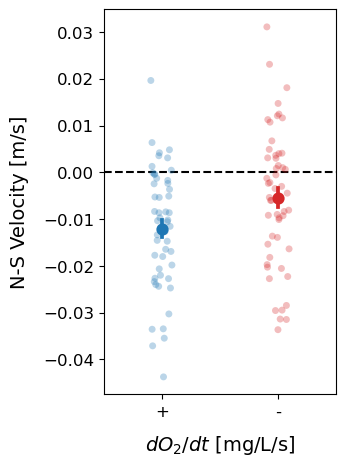

In [298]:
fig, ax = plt.subplots(figsize=(3, 5))
order = ['pos', 'neg']
palette = ['tab:blue', 'tab:red']

ax.axhline(0, color='black', linestyle='--')
sns.stripplot(df, x='sign', y='vel', order=order, hue='sign', hue_order=order, palette=palette, alpha=0.3, ax=ax)
sns.pointplot(df, x='sign',y='vel', order=order, hue='sign', hue_order=order, palette=palette, errorbar=('se', 1), ax=ax)

ax.set_xlabel(r'$dO_{2}/dt$ [mg/L/s]', fontsize=14, labelpad=10)
ax.set_ylabel('N-S Velocity [m/s]', fontsize=14, labelpad=10)
ax.set_xticks([0, 1], labels=['+', '-'])
ax.tick_params(axis='both', labelsize=12)

plt.savefig('../gallery/zug_retreat/dodt_vel.svg', bbox_inches='tight')
plt.show()

### Boundary Mixing

In [90]:
lake = 'Zug'
year = '2025'
date = '20251126'

dpath_L2 = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [91]:
eps_c, eps_s = [], []

for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)
    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPC
    if any(f in fpath for f in ['VMP005', 'VMP009', 'VMP010']):
        eps_c.append(eps)
    
    # VMPS
    elif any(f in fpath for f in ['VMP003', 'VMP004']):
        eps_s.append(eps)

eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')

# 5-meter binned median
bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

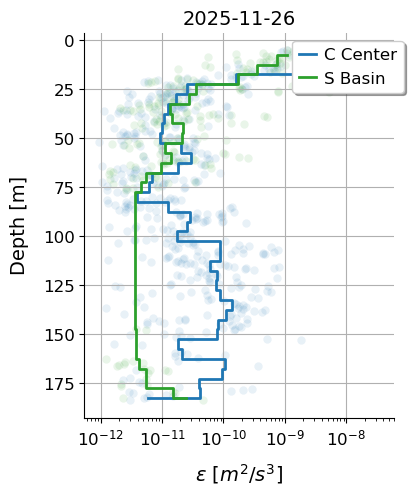

In [92]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:green', alpha=0.1, ax=ax)
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:green', linewidth=2, drawstyle="steps-mid", ax=ax, label='S Basin')

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2025-11-26', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper center', bbox_to_anchor=(0.85, 1), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.show()

In [93]:
lake = 'Zug'
year = '2025'
date = '20251127'

dpath_L2 = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [98]:
eps_c, eps_s = [], []

for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)
    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPC
    if any(f in fpath for f in ['VMP004', 'VMP005', 'VMP006']):
        eps_c.append(eps)
    
    # VMPS
    elif any(f in fpath for f in ['VMP002', 'VMP003']):
        eps_s.append(eps)

eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')

# 5-meter binned median
bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

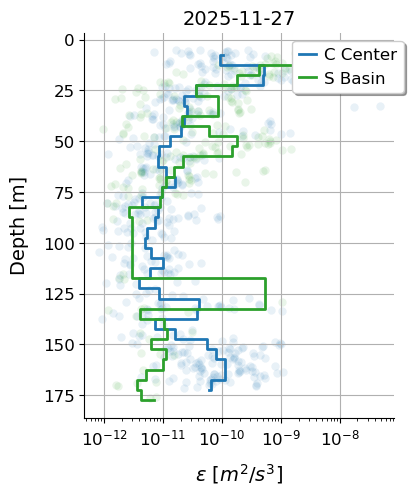

In [99]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:green', alpha=0.1, ax=ax)
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:green', linewidth=2, drawstyle="steps-mid", ax=ax, label='S Basin')

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2025-11-27', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper center', bbox_to_anchor=(0.85, 1), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.show()

In [104]:
lake = 'Zug'
year = '2025'
date = '20251128'

dpath_L2 = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [105]:
eps_w, eps_c = [], []

for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)
    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPW
    if any(f in fpath for f in ['VMP005', 'VMP006', 'VMP007', 'VMP008']):
        eps_w.append(eps)
    
    # VMPC
    elif any(f in fpath for f in ['VMP002', 'VMP003', 'VMP004']):
        eps_c.append(eps)

eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')

# 5-meter binned median
bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

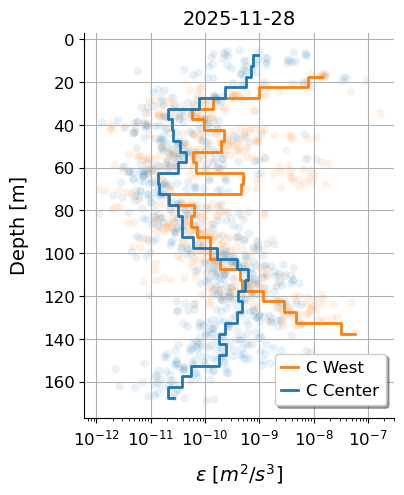

In [113]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:orange', alpha=0.1, ax=ax)
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:orange', linewidth=2, drawstyle="steps-mid", ax=ax, label='C West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2025-11-28', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='lower right', bbox_to_anchor=(1, 0.01), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.savefig('../gallery/zug_retreat/eps_28_11_2025.svg', bbox_inches='tight')
plt.show()

In [121]:
lake = 'Zug'
year = '2026'
date = '20260113'

dpath_L2 = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [122]:
eps_w, eps_c, eps_s = [], [], []
for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)
    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    
    # VMPW
    if 'DAT_057' in fpath:
        eps_w.append(eps)

    # VMPC
    elif 'DAT_055' in fpath or 'DAT_059' in fpath:
        eps_c.append(eps)
    
    # VMPS
    elif 'DAT_053' in fpath:
        eps_s.append(eps)

eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')

# 5 meter bins
bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

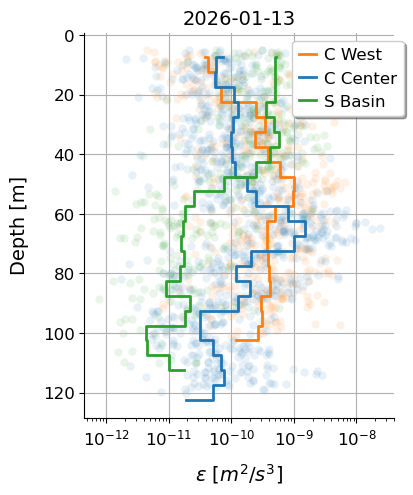

In [123]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:orange', alpha=0.1, ax=ax)
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:orange', linewidth=2, drawstyle="steps-mid", ax=ax, label='C West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:green', alpha=0.1, ax=ax)
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:green', linewidth=2, drawstyle="steps-mid", ax=ax, label='S Basin')

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2026-01-13', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper center', bbox_to_anchor=(0.85, 1), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.savefig('../gallery/zug_retreat/eps_13_1_2026.svg', bbox_inches='tight')
plt.show()

In [127]:
lake = 'Zug'
year = '2026'
date = '20260213'

dpath_L2 = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [129]:
eps_w, eps_c, eps_s = [], [], []
for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)
    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    
    # VMPW
    if 'DAT_094' in fpath:
        eps_w.append(eps)

    # VMPC
    elif 'DAT_093' in fpath:
        eps_c.append(eps)
    
    # VMPS
    elif 'DAT_095' in fpath:
        eps_s.append(eps)

eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')
eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')

# 5 meter bins
bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

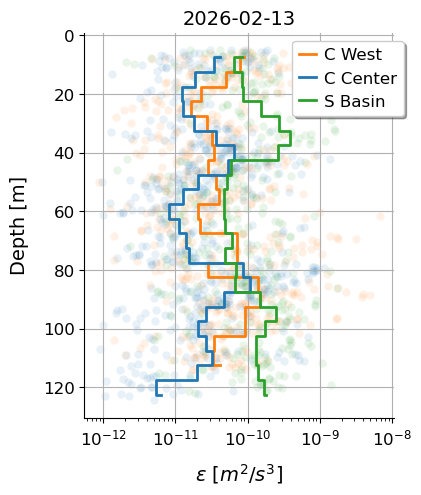

In [131]:
fig, ax = plt.subplots(figsize=(4, 5))

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color='tab:orange', alpha=0.1, ax=ax)
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color='tab:orange', linewidth=2, drawstyle="steps-mid", ax=ax, label='C West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color='tab:blue', alpha=0.1, ax=ax)
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color='tab:blue', linewidth=2, drawstyle="steps-mid", ax=ax, label='C Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color='tab:green', alpha=0.1, ax=ax)
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color='tab:green', linewidth=2, drawstyle="steps-mid", ax=ax, label='S Basin')

ax.set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('2026-02-13', fontsize=14)

ax.invert_yaxis()
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=12)
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper center', bbox_to_anchor=(0.85, 1), 
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

plt.savefig('../gallery/zug_retreat/eps_13_2_2026.svg', bbox_inches='tight')
plt.show()

#### Oxygen overturns

LZW, oxygen loggers 117.2 v. 128 m, velocity 107-131 m.

In [299]:
date = '2026-04-09'
loc = 'LZW'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'minidot'")

ds_do = load_oxygen_logger_chain(di_m_sel)

C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\402739537.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'minidot'")
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [454]:
do_top = ds_do.do2_conc.sel(depth=115, method='nearest')
do_bot = ds_do.do2_conc.sel(depth=130, method='nearest')
do_diff = do_top - do_bot
do_top.depth.item(), do_bot.depth.item()

(117.2, 128.0)

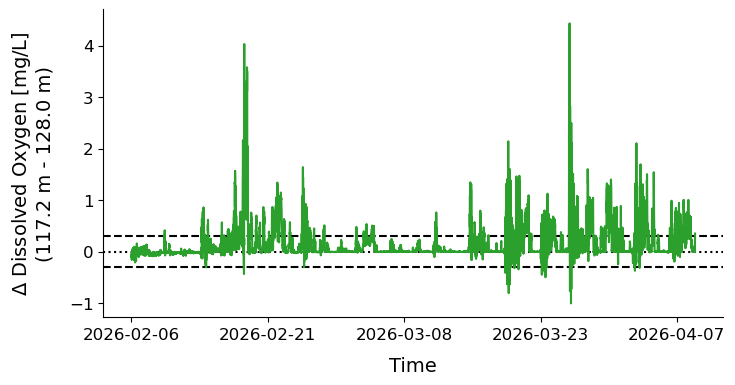

In [467]:
err = 0.3    # minidot accuracy

fig, ax = plt.subplots(figsize=(8, 4))

ax.axhline(0, color='black', linestyle=':')
ax.axhline(err, color='black', linestyle='--')
ax.axhline(-err, color='black', linestyle='--')
sns.lineplot(x=do_diff.time, y=do_diff, color='tab:green', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel(r'$\Delta$' + f' Dissolved Oxygen [mg/L]\n({do_top.depth.item()} m - {do_bot.depth.item()} m)', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/zug_retreat/do_diff.svg', bbox_inches='tight')
plt.show()

In [488]:
mask = do_diff < -err
t_sel = do_diff.time.where(mask, drop=True)

In [443]:
date = '2026-04-09'
loc = 'LZW'
row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]

mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds = areader.load().sel(time=slice(t_start, t_end))
ds = ewg.signal.valid_depths(ds, 0.5)    # keep depth bins with > 50% data

C:\Users\herremha\AppData\Local\Temp\ipykernel_30824\1579516800.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]


In [501]:
# horizontal flow speed
u = ds.vel.sel(dir='E')
v = ds.vel.sel(dir='N')
speed = np.sqrt(u**2 + v**2).mean(dim='depth')

speed_sel = np.unique(speed.reindex(time=t_neg, method='nearest'))

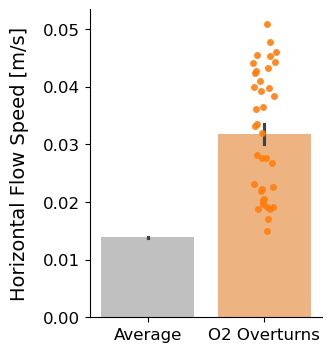

In [531]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.barplot(x=0, y=speed, color='silver', errorbar=('se', 1), ax=ax)

sns.stripplot(x=1, y=speed_sel, color='tab:orange', alpha=0.9, ax=ax)
sns.barplot(x=1, y=speed_sel, color='tab:orange', alpha=0.6, errorbar=('se', 1), ax=ax)

ax.set_ylabel('Horizontal Flow Speed [m/s]', fontsize=14, labelpad=10)
ax.set_xticks([0, 1], labels=['Average', 'O2 Overturns'])
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../gallery/zug_retreat/speed_O2_overturns.svg', bbox_inches='tight')
plt.show()

#### Thorpe scales

N/S basin v. constriction center v. constriction west.  Only profiles > 110 meters depth, filter for below 80 meters prior to Thorpe displacement calculation.

In [537]:
t_start = '2025-10-29'
di_sel = di_ctd[di_ctd['date'] >= t_start]

pl_n = ["P4", "VMPN"]
pl_w = ["P6W", "VMPW"]
pl_c = ["P6", "VMPC", "PC", "P7"]
pl_s = ["P10", "VMPS", "LZ3"]

In [543]:
data = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    if p.profile_loc in pl_n + pl_w + pl_c + pl_s:
        ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
        ds = ctdreader.load()

        if ds['depth'].max() < 110:
            continue
        
        # select out below 80 meters (hypolimion/deep water)
        ds = ds.sel(depth=slice(80, 110))
        
        # thorpe displacement
        rho = ds['rho']
        depth = ds['depth']
        rho_ra = ewg.signal.rolling_average_z(rho)
        rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
        thorpe_displacement = depth - rho_ra_sort.depth.values
        thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

        data.append({
            'date': p.date,
            'profile_loc': p.profile_loc,
            'basin': 'N' if p.profile_loc in pl_n else 'W' if p.profile_loc in pl_w else 'C' if p.profile_loc in pl_c else 'S',
            'thorpe_scale': thorpe_scale
        })

data = pd.DataFrame(data)

  0%|          | 0/189 [00:00<?, ?it/s]

In [546]:
data.groupby("basin").count()

,date,profile_loc,thorpe_scale
basin,,,
C,52,52,52
N,9,9,9
S,20,20,20
W,16,16,16


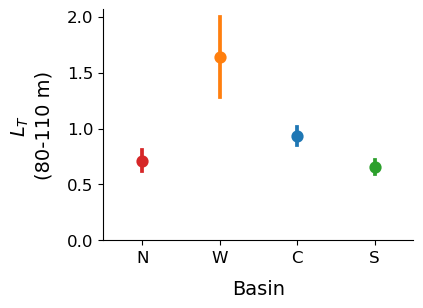

In [561]:
fig, ax = plt.subplots(figsize=(4, 3))
order = ['N', 'W', 'C', 'S']
palette = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green']

sns.pointplot(data, x='basin', y='thorpe_scale', order=order, hue='basin', hue_order=order, palette=palette, errorbar=('se', 1), linestyle='none', ax=ax)

ax.set_xlabel('Basin', fontsize=14, labelpad=10)
ax.set_ylabel(r'$L_{T}$' + '\n(80-110 m)', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_ylim(0, None)

plt.savefig('../gallery/zug_retreat/thorpe_basin.svg', bbox_inches='tight')
plt.show()

### Hydraulic jump

In [8]:
date = '2024-10-17'

# constriction
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(46, 53)
ds_adcp_c = load_adcp_chain(di_m_sel, gap)

# S basin
loc = "LZS'"
row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp_s = areader.load().sel(time=slice(t_start, t_end))
ds_adcp_s = ewg.signal.valid_depths(ds_adcp_s, 0.5)    # keep depth bins with > 50% data

C:\Users\herremha\AppData\Local\Temp\ipykernel_27564\459794493.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_27564\2324356044.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
C:\Users\herremha\AppData\Local\Temp\ipykernel_27564\459794493.py:11: FutureWarning: 

In [9]:
vc1 = ds_adcp_c.vel.sel(dir='N', depth=slice(60, 80))
vs1 = ds_adcp_s.vel.sel(dir='N', depth=slice(60, 80))

vc_avg1 = vc1.mean(dim='depth')
vs_avg1 = vs1.mean(dim='depth')

# filter for southward flows
mask1 = (vc_avg1 < 0) & (vs_avg1 < 0)

vc_sel1 = vc_avg1.where(mask1, drop=True)
vs_sel1 = vs_avg1.where(mask1, drop=True)

In [6]:
date = '2025-04-24'

# constriction
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(96, 118)
ds_adcp_c = load_adcp_chain(di_m_sel, gap)

# S basin
loc = "LZS'"
row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp_s = areader.load().sel(time=slice(t_start, t_end))
ds_adcp_s = ewg.signal.valid_depths(ds_adcp_s, 0.5)    # keep depth bins with > 50% data

C:\Users\herremha\AppData\Local\Temp\ipykernel_27564\2796147217.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_27564\2324356044.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
C:\Users\herremha\AppData\Local\Temp\ipykernel_27564\2796147217.py:11: FutureWarning

In [7]:
vc2 = ds_adcp_c.vel.sel(dir='N', depth=slice(60, 80))
vs2 = ds_adcp_s.vel.sel(dir='N', depth=slice(60, 80))
vs2 = vs2.reindex(time=vc2.time, method='nearest')    # incongruent time dimensions

vc_avg2 = vc2.mean(dim='depth')
vs_avg2 = vs2.mean(dim='depth')

# filter for soutward flows
mask2 = (vc_avg2 < 0) & (vs_avg2 < 0)

vc_sel2 = vc_avg2.where(mask2, drop=True)
vs_sel2 = vs_avg2.where(mask2, drop=True)

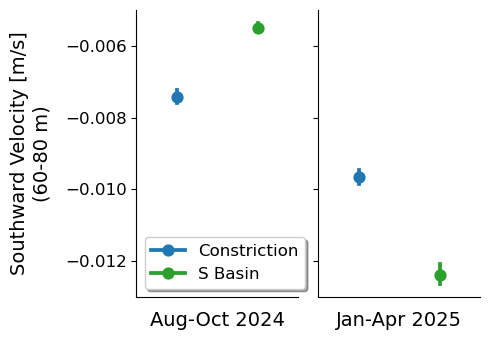

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 3.5), sharey=True)

# Aug-Oct
sns.pointplot(x=0, y=vc_sel1, color='tab:blue', ax=ax[0], label='Constriction')
sns.pointplot(x=1, y=vs_sel1, color='tab:green', ax=ax[0], label='S Basin')

# Jan-Apr
sns.pointplot(x=0, y=vc_sel2, color='tab:blue', ax=ax[1])
sns.pointplot(x=1, y=vs_sel2, color='tab:green', ax=ax[1])

ax[0].set_ylabel('Southward Velocity [m/s]\n(60-80 m)', fontsize=14, labelpad=10)
ax[0].set_xlabel('Aug-Oct 2024', fontsize=14, labelpad=10)
ax[1].set_xlabel('Jan-Apr 2025', fontsize=14, labelpad=10)
ax[0].tick_params(axis='y', labelsize=12)

for i in range(len(ax)):
    ax[i].set_xticks([])
    ax[i].spines[['right', 'top']].set_visible(False)

ax[0].legend(fontsize=12, shadow=True, loc='lower left')

plt.tight_layout()
plt.savefig('../gallery/zug_retreat/hydraulic_jump.svg', bbox_inches='tight')
plt.show()

In [64]:
g = 9.81
rho1 = 1000.14
rho2 = 1000.16
h1 = 70
h2 = 100
U1 = 0.02
U2 = 0.02

g_prime = g * (rho2 - rho1) / rho2

Fr1 = U1 / np.sqrt(g_prime * h1)
Fr2 = U2 / np.sqrt(g_prime * h2)

Fr1, Fr2, Fr1**2 + Fr2**2

(np.float64(0.17067354726199022),
 np.float64(0.14279573458088154),
 np.float64(0.04952008154948438))

### Intrusive layers

In [12]:
date = '2026-04-09'
loc = 'LZW'
row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]

# ADCP
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds = areader.load().sel(time=slice(t_start, t_end))
ds = ewg.signal.valid_depths(ds, 0.5)    # keep depth bins with > 50% data

C:\Users\herremha\AppData\Local\Temp\ipykernel_27564\4021366737.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]


In [6]:
tf = pd.to_datetime('2026-02-20')
u = ds.vel.sel(dir='E', time=slice(None, tf))

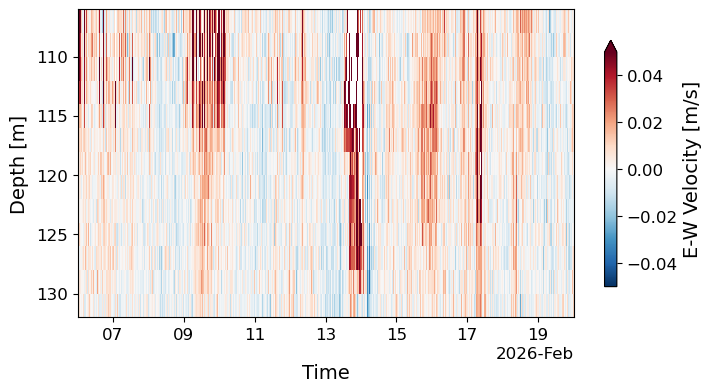

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

pc = u.plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink': 0.8, 'label': 'E-W Velocity [m/s]'}, ax=ax, rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()

plt.savefig('../gallery/zug_retreat/intrusive_vel.svg', bbox_inches='tight')
plt.show()

In [51]:
S2 = ewg.datsci.efd.vertical_shear(ds['vel'])

tf = pd.to_datetime('2026-02-20')
S2 = S2.sel(time=slice(None, tf)).isel(depth=slice(1, -1))

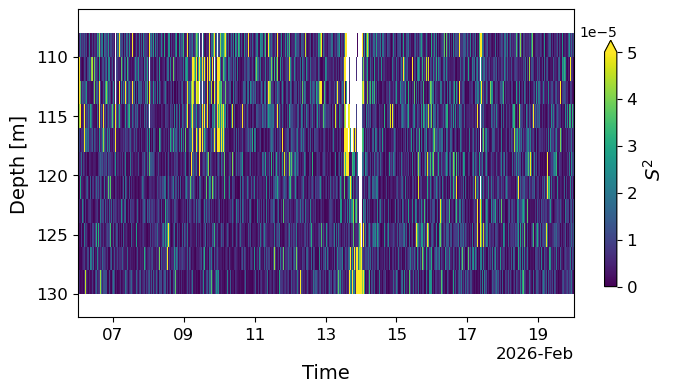

In [54]:
fig, ax = plt.subplots(figsize=(8, 4))

pc = S2.plot(x='time', y='depth', cmap='viridis', vmin=0, vmax=0.00005, cbar_kwargs={'shrink': 0.8, 'label': r'$S^{2}$'}, ax=ax, rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('')
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.set_ylim(106, 132)
ax.invert_yaxis()

plt.savefig('../gallery/zug_retreat/intrusive_S2.svg', bbox_inches='tight')
plt.show()

In [9]:
di_ctd_sel = di_ctd[di_ctd['profile_loc'].isin(["P6W", "VMPW"])]

data = []
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()

    if ds['depth'].max() < 100:
        continue
    
    # select out below 100 meters
    ds = ds.sel(depth=slice(100, None))
    
    # thorpe displacement
    rho = ds['rho']
    depth = ds['depth']
    rho_ra = ewg.signal.rolling_average_z(rho)
    rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
    thorpe_displacement = depth - rho_ra_sort.depth.values
    thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

    data.append({
        'date': p.date,
        'thorpe_scale': thorpe_scale
    })

data = pd.DataFrame(data)

  0%|          | 0/20 [00:00<?, ?it/s]

In [15]:
data

,date,thorpe_scale
0,2024-11-08,1.763439
1,2025-04-02,0.785476
2,2025-11-28,2.763218
3,2026-01-12,6.559405
4,2026-01-13,1.190011
5,2026-01-28,1.477304
6,2026-01-28,0.734653
7,2026-02-13,0.413421
8,2026-02-13,0.565536
9,2026-02-27,1.632303


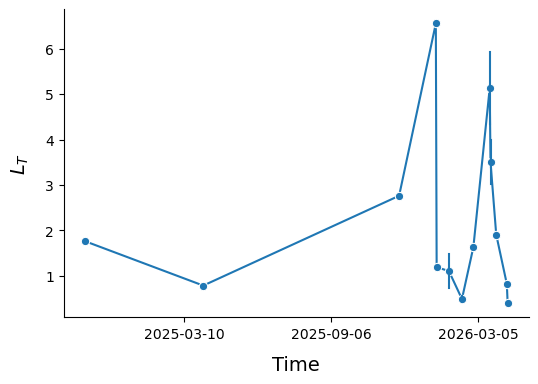

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.lineplot(data, x='date', y='thorpe_scale', marker='o', errorbar=('se', 1), err_style='bars', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel(r'$L_{T}$', fontsize=14, labelpad=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=180))

ax.spines[['right', 'top']].set_visible(False)

plt.show()

### Venturi effect

In [4]:
date = '2024-10-17'

# constriction
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(46, 53)
ds_adcp_c = load_adcp_chain(di_m_sel, gap)

# S basin
loc = "LZS'"
row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp_s = areader.load().sel(time=slice(t_start, t_end))
ds_adcp_s = ewg.signal.valid_depths(ds_adcp_s, 0.5)    # keep depth bins with > 50% data

C:\Users\herremha\AppData\Local\Temp\ipykernel_14600\459794493.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_14600\2324356044.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
C:\Users\herremha\AppData\Local\Temp\ipykernel_14600\459794493.py:11: FutureWarning: 

In [10]:
vc1 = ds_adcp_c.vel.sel(dir='N', depth=slice(60, 80))
vs1 = ds_adcp_s.vel.sel(dir='N', depth=slice(60, 80))

vc_avg1 = vc1.mean(dim='depth')
vs_avg1 = vs1.mean(dim='depth')

# filter for nortward flows
mask1 = (vc_avg1 > 0) & (vs_avg1 > 0)

vc_sel1 = vc_avg1.where(mask1, drop=True)
vs_sel1 = vs_avg1.where(mask1, drop=True)

In [29]:
date = '2025-04-24'

# constriction
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(96, 118)
ds_adcp_c = load_adcp_chain(di_m_sel, gap)

# S basin
loc = "LZS'"
row = di_m.query("date == @date and location == @loc and sensor == 'adcp'").iloc[0]
mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve - pd.Timedelta(days=1)
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp_s = areader.load().sel(time=slice(t_start, t_end))
ds_adcp_s = ewg.signal.valid_depths(ds_adcp_s, 0.5)    # keep depth bins with > 50% data

C:\Users\herremha\AppData\Local\Temp\ipykernel_14600\2796147217.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_14600\2324356044.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
C:\Users\herremha\AppData\Local\Temp\ipykernel_14600\2796147217.py:11: FutureWarning

In [41]:
vc2 = ds_adcp_c.vel.sel(dir='N', depth=slice(60, 80))
vs2 = ds_adcp_s.vel.sel(dir='N', depth=slice(60, 80))
vs2 = vs2.reindex(time=vc2.time, method='nearest')    # incongruent time dimensions

vc_avg2 = vc2.mean(dim='depth')
vs_avg2 = vs2.mean(dim='depth')

# filter for nortward flows
mask2 = (vc_avg2 > 0) & (vs_avg2 > 0)

vc_sel2 = vc_avg2.where(mask2, drop=True)
vs_sel2 = vs_avg2.where(mask2, drop=True)

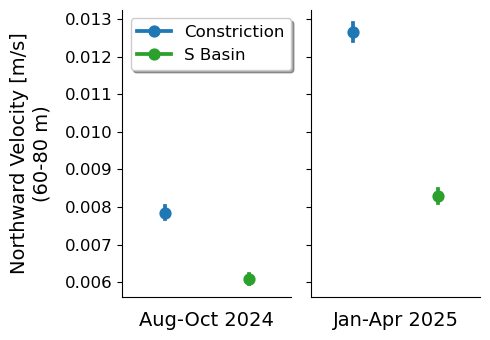

In [70]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(5, 3.5), sharey=True)

# Aug-Oct
sns.pointplot(x=0, y=vc_sel1, color='tab:blue', ax=ax[0], label='Constriction')
sns.pointplot(x=1, y=vs_sel1, color='tab:green', ax=ax[0], label='S Basin')

# Jan-Apr
sns.pointplot(x=0, y=vc_sel2, color='tab:blue', ax=ax[1])
sns.pointplot(x=1, y=vs_sel2, color='tab:green', ax=ax[1])

ax[0].set_ylabel('Northward Velocity [m/s]\n(60-80 m)', fontsize=14, labelpad=10)
ax[0].set_xlabel('Aug-Oct 2024', fontsize=14, labelpad=10)
ax[1].set_xlabel('Jan-Apr 2025', fontsize=14, labelpad=10)
ax[0].tick_params(axis='y', labelsize=12)

for i in range(len(ax)):
    ax[i].set_xticks([])
    ax[i].spines[['right', 'top']].set_visible(False)

ax[0].legend(fontsize=12, shadow=True, loc='upper left')

plt.tight_layout()
plt.savefig('../gallery/zug_retreat/venturi.svg', bbox_inches='tight')
plt.show()